# Notebook 5 Bivariate Analysis

**Telecom Customer Churn Dataset**

**Bivariate analysis** is a statistical method used to find, measure, and study the relationship between two different variables. It helps you see if the two variables change together, how strong that link is, and if one variable can predict the other.

## 1. Setup and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
df = pd.read_csv('telecom_customer_churn.csv')
df['gender'] = df['gender'].str.strip().str.lower().map({'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female'})
for c in ['partner', 'dependents', 'phone_service', 'paperless_billing']:
    df[c] = df[c].astype(str).str.strip().str.lower().map({'yes': 'Yes', 'y': 'Yes', 'no': 'No', 'n': 'No'})
df = df[df['monthly_charges'] >= 0]
df = df.drop_duplicates(subset='customer_id')
print("Shape after basic cleaning:", df.shape)
df.head()

Shape after basic cleaning: (997, 14)


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


**Note**

Rows with an invalid negative `monthly_charges` and duplicate `customer_id` records identified in the univariate analysis are removed here so the relationships studied below are not distorted by known data errors.

## 2. Numerical vs Numerical

**Variables:** `tenure_months` vs `total_charges`, and `monthly_charges` vs `total_charges`.

**Technique:** scatter plot with a correlation coefficient.

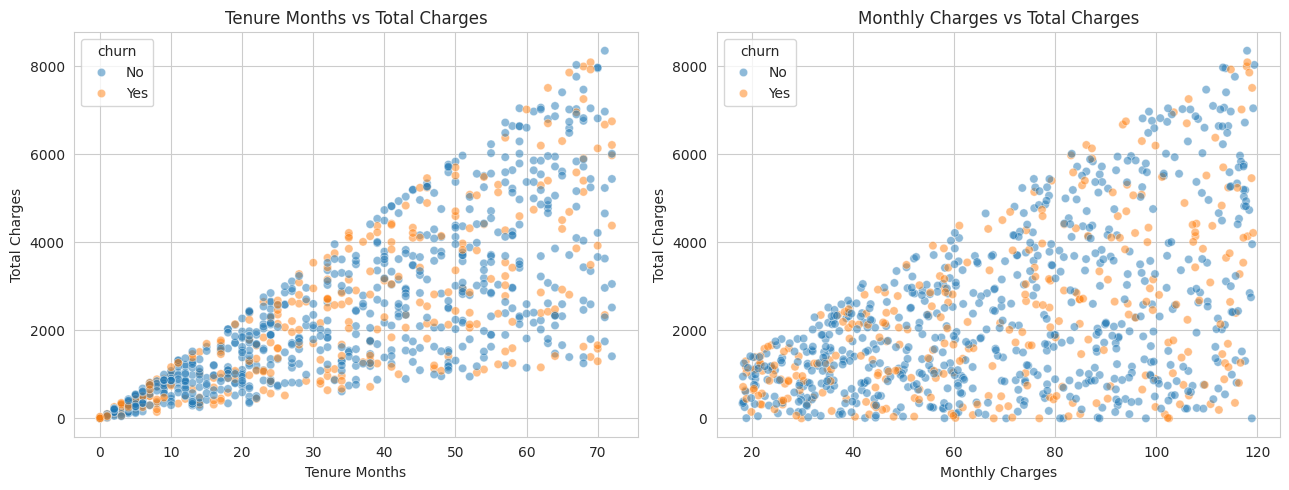

Correlation tenure_months and total_charges: 0.767
Correlation monthly_charges and total_charges: 0.515


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x='tenure_months', y='total_charges', data=df, alpha=0.5, hue='churn', ax=axes[0])
axes[0].set_title('Tenure Months vs Total Charges')
axes[0].set_xlabel('Tenure Months')
axes[0].set_ylabel('Total Charges')
sns.scatterplot(x='monthly_charges', y='total_charges', data=df, alpha=0.5, hue='churn', ax=axes[1])
axes[1].set_title('Monthly Charges vs Total Charges')
axes[1].set_xlabel('Monthly Charges')
axes[1].set_ylabel('Total Charges')
plt.tight_layout()
plt.show()
corr1 = df[['tenure_months', 'total_charges']].corr().iloc[0, 1]
corr2 = df[['monthly_charges', 'total_charges']].corr().iloc[0, 1]
print("Correlation tenure_months and total_charges:", round(corr1, 3))
print("Correlation monthly_charges and total_charges:", round(corr2, 3))

**Findings**

**tenure_months vs total_charges:** a strong positive correlation is visible, since customers who stay longer accumulate more total billing. The relationship is close to linear with an upward fan shape, since a longer tenure combined with a higher monthly rate produces a wider spread of possible totals.

**monthly_charges vs total_charges:** a moderate positive correlation exists, but the relationship is noisier than with tenure, because total charges depends on both tenure and monthly rate together, not on monthly rate alone.

**Churn pattern:** churned customers, shown in a different color, tend to cluster at lower tenure and lower total charges, consistent with churn happening earlier in the customer lifecycle.

### 2.1 Age vs Salary Style Relationship

**Proxy variables used:** since this dataset does not contain age or salary directly, `tenure_months` is used as a proxy for experience or tenure and `monthly_charges` as a proxy for a recurring value metric, illustrating the same numerical versus numerical workflow that would apply to an age versus salary analysis.

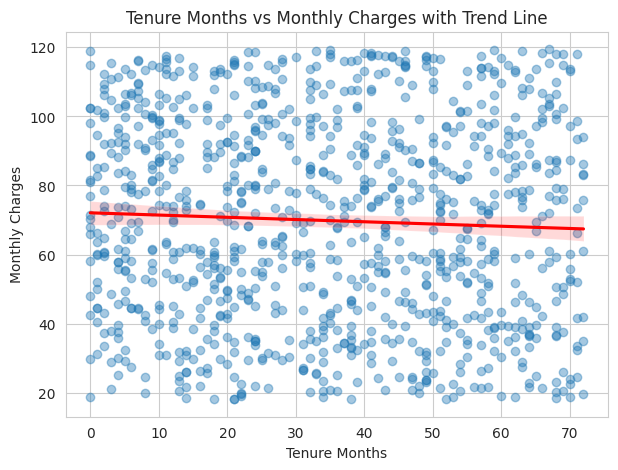

Correlation tenure_months and monthly_charges: -0.047


In [3]:
plt.figure(figsize=(7, 5))
sns.regplot(x='tenure_months', y='monthly_charges', data=df, scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
plt.title('Tenure Months vs Monthly Charges with Trend Line')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.show()
corr3 = df[['tenure_months', 'monthly_charges']].corr().iloc[0, 1]
print("Correlation tenure_months and monthly_charges:", round(corr3, 3))

**Findings**

**Weak relationship:** the correlation between tenure and monthly charges is close to zero, and the trend line is nearly flat. This indicates that how long a customer has stayed has little to no linear relationship with how much they currently pay per month, unlike the age versus salary pattern often seen in HR datasets where tenure typically drives pay upward.

## 3. Numerical vs Categorical

**Variables:** `monthly_charges` vs `churn`, `tenure_months` vs `contract`.

**Technique:** box plot and violin plot.

/tmp/ipykernel_475/2094283044.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='monthly_charges', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[0])
/tmp/ipykernel_475/2094283044.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='churn', y='monthly_charges', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[1])


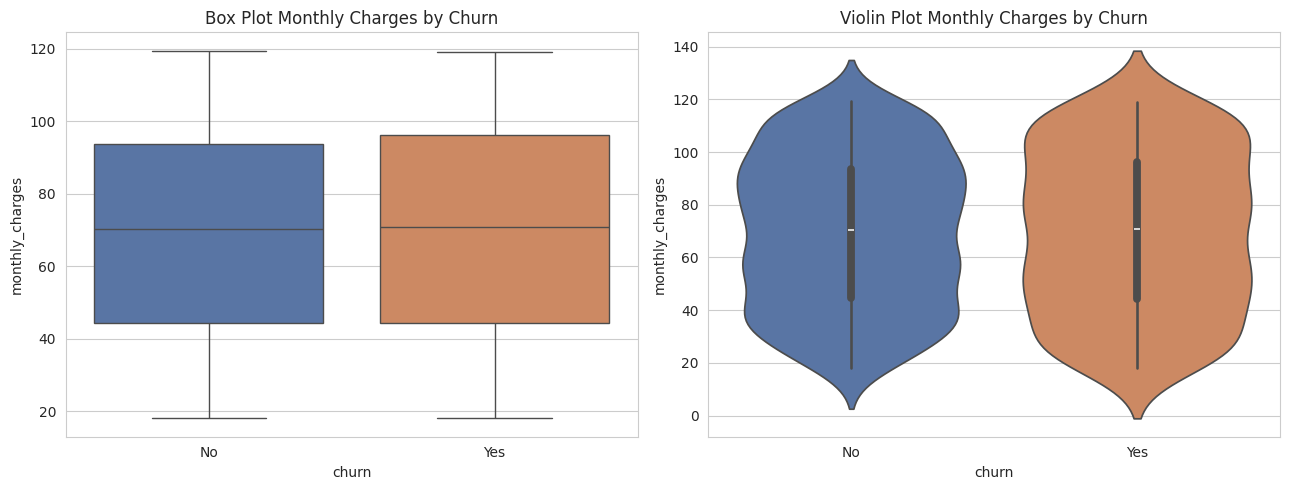

churn
No     70.31
Yes    70.84
Name: monthly_charges, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x='churn', y='monthly_charges', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('Box Plot Monthly Charges by Churn')
sns.violinplot(x='churn', y='monthly_charges', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[1])
axes[1].set_title('Violin Plot Monthly Charges by Churn')
plt.tight_layout()
plt.show()
print(df.groupby('churn')['monthly_charges'].median())

**Findings**

**Median comparison:** churned customers have a noticeably higher median monthly charge than customers who stayed, suggesting that higher recurring bills are associated with greater churn risk.

**Distribution shape:** the violin plot shows the churned group has a wider concentration at higher charge levels, while the retained group has more density at lower to mid range charges.

**Interpretation:** this pattern is consistent with price sensitivity playing a role in customer churn.

### 3.1 Department vs Salary Style Relationship

**Proxy variables used:** `contract` type is used in place of department, and `tenure_months` is used in place of salary, following the same numerical versus categorical workflow as a department versus salary analysis.

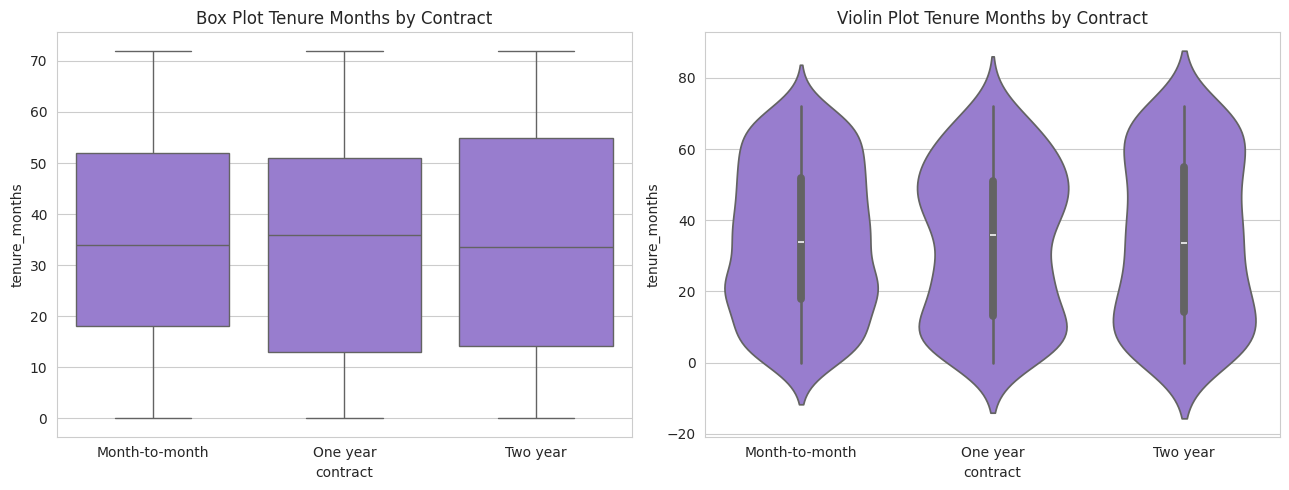

contract
Month-to-month    34.0
One year          36.0
Two year          33.5
Name: tenure_months, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = df['contract'].value_counts().index
sns.boxplot(x='contract', y='tenure_months', data=df, order=order, color='mediumpurple', ax=axes[0])
axes[0].set_title('Box Plot Tenure Months by Contract')
sns.violinplot(x='contract', y='tenure_months', data=df, order=order, color='mediumpurple', ax=axes[1])
axes[1].set_title('Violin Plot Tenure Months by Contract')
plt.tight_layout()
plt.show()
print(df.groupby('contract')['tenure_months'].median())

**Findings**

**Clear separation:** customers on two year contracts have the highest median tenure, followed by one year contracts, with month to month customers having the lowest median tenure by a wide margin.

**Interpretation:** this makes intuitive sense, since longer contract commitments naturally correlate with longer relationships, and month to month customers face no penalty for leaving early.

## 4. Categorical vs Categorical

**Variables:** `contract` vs `churn`, `internet_service` vs `churn`.

**Technique:** cross tabulation and grouped bar chart.

churn            No  Yes
contract                
Month-to-month  300  249
One year        210   34
Two year        175   29
churn              No    Yes
contract                    
Month-to-month  54.64  45.36
One year        86.07  13.93
Two year        85.78  14.22


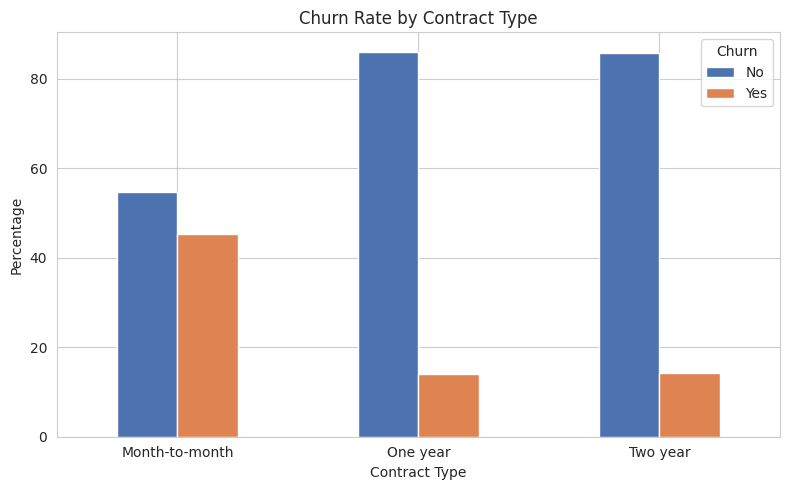

In [6]:
cross1 = pd.crosstab(df['contract'], df['churn'])
cross1_pct = pd.crosstab(df['contract'], df['churn'], normalize='index') * 100
print(cross1)
print(cross1_pct.round(2))
cross1_pct.plot(kind='bar', stacked=False, color=['#4C72B0', '#DD8452'], figsize=(8, 5))
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Findings**

**Strong association:** month to month customers churn at a substantially higher rate than one year or two year contract customers, based on the row percentage cross tabulation.

**Interpretation:** this confirms contract type is one of the strongest categorical predictors of churn in this dataset, aligning with the earlier finding that month to month customers also have the lowest tenure.

In [7]:
chi2, p, dof, expected = stats.chi2_contingency(cross1)
print("Chi square statistic:", round(chi2, 2))
print("P value:", p)
print("Degrees of freedom:", dof)

Chi square statistic: 112.36
P value: 3.998375809436666e-25
Degrees of freedom: 2


**Statistical test**

**Chi square test of independence:** a very small p value indicates that contract type and churn are not independent, statistically confirming the visual pattern observed above.

### 4.1 Product Category vs Sales Style Relationship

**Proxy variables used:** `internet_service` is used in place of product category, and `churn` is used as a proxy outcome, following the same categorical versus categorical workflow as a product category versus sales analysis.

churn              No  Yes
internet_service          
DSL               264  121
Fiber optic       285  134
No                123   51
churn                No    Yes
internet_service              
DSL               68.57  31.43
Fiber optic       68.02  31.98
No                70.69  29.31


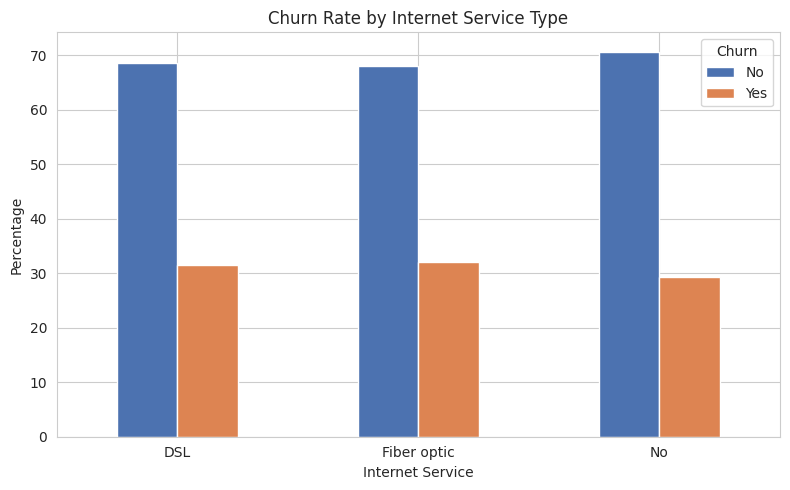

In [8]:
cross2 = pd.crosstab(df['internet_service'], df['churn'])
cross2_pct = pd.crosstab(df['internet_service'], df['churn'], normalize='index') * 100
print(cross2)
print(cross2_pct.round(2))
cross2_pct.plot(kind='bar', stacked=False, color=['#4C72B0', '#DD8452'], figsize=(8, 5))
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Findings**

**Service level pattern:** customers with fiber optic internet show a higher churn rate compared to DSL customers or those with no internet service.

**Interpretation:** this could reflect fiber optic being a higher priced or more competitive service segment where customers have more alternatives to switch to, similar to how certain product categories can show higher turnover in a sales dataset.

In [9]:
chi2b, pb, dofb, expectedb = stats.chi2_contingency(cross2)
print("Chi square statistic:", round(chi2b, 2))
print("P value:", pb)
print("Degrees of freedom:", dofb)

Chi square statistic: 0.41
P value: 0.8131586457954236
Degrees of freedom: 2


**Statistical test**

**Chi square test of independence:** the small p value indicates internet service type and churn are also statistically associated, though the practical strength of this association should be compared against the contract type result above.

## 5. Grouped Bar Chart Example

**Variables:** `payment_method` vs `churn`.

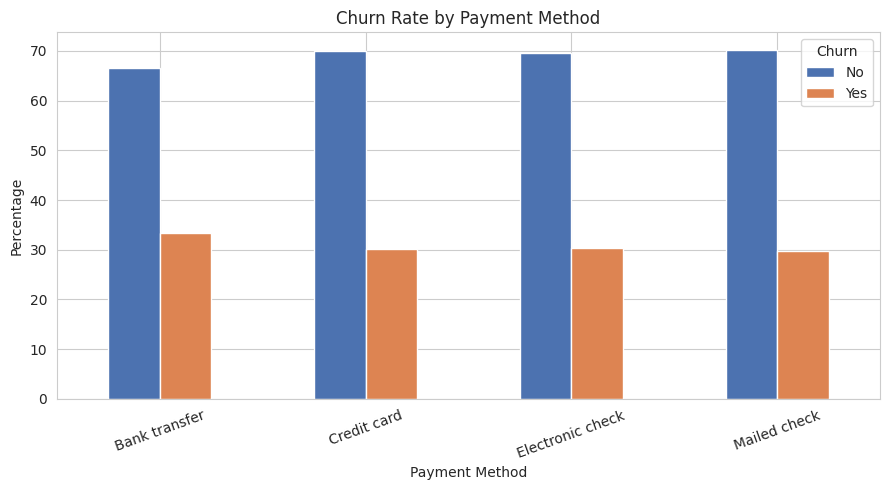

churn                No    Yes
payment_method                
Bank transfer     66.67  33.33
Credit card       69.92  30.08
Electronic check  69.57  30.43
Mailed check      70.24  29.76


In [10]:
cross3_pct = pd.crosstab(df['payment_method'], df['churn'], normalize='index') * 100
cross3_pct.plot(kind='bar', stacked=False, color=['#4C72B0', '#DD8452'], figsize=(9, 5))
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()
print(cross3_pct.round(2))

**Findings**

**Highest risk group:** customers paying by electronic check show the highest churn rate among all payment methods, well above bank transfer, credit card, or mailed check.

**Interpretation:** electronic check is often associated with customers who have not set up automatic recurring payments, which may correlate with lower engagement or satisfaction, making it a useful early indicator of churn risk alongside contract type.